# Meep Benchmark

In order to investigate Tidy3D speed advantage, and also confirm its robustness, we will compare the results of a MMI power divider, available in our [application library](https://tidy3d.simulation.cloud/workbench?taskId=pa-275578d5-1d58-4c19-81da-e137c9abe712), with the open source software Meep.

In [1]:
import meep as mp 
import tidy3d as td
from tidy3d import web
import numpy as np
from time import time

# FDTD Simulation

The model is based on our web GUI example. Bellow is the code exported directly from the GUI, with minor modifications:

In [2]:
# defining parameters
si_index = 3.48
sio2_index = 1.46
central_wavelength = 1.55
waveguide_width = 0.5
waveguide_thickness = 0.22
waveguide_length = 2
mmi_width = 3.6
mmi_length = 11.5
output_separation = 0.6
taper_width = 1.2
taper_length = 20.05
SiO2_medium = td.Medium(
    name = 'SiO2', 
    permittivity = 2.1315999999999997, 
)

# operating frequency
freq0 = 193.414e12
fwidth = 6.24568e12

freqs = np.linspace(freq0-fwidth,freq0+fwidth,50)

# mode source
Mode_source = td.ModeSource(
    name = 'Mode source', 
    num_freqs = 10,
    center = [-mmi_length / 2-taper_length-waveguide_length / 2, 0, 0], 
    size = [0, 3 * waveguide_width, 4 * waveguide_thickness], 
    source_time = td.GaussianPulse(freq0 = 193414489032258.06, fwidth = 6245676208333.328, ), 
    direction = '+', 
    mode_spec = td.ModeSpec(target_neff = 3.48, ), 
)

# defining monitors for calculating transmittance and field visualization

Flux_monitor = td.FluxMonitor(
    name = 'Flux monitor', 
    center = [mmi_length / 2 + taper_length + waveguide_length / 2, (output_separation + taper_width) / 2, 0], 
    size = [0, 3 * waveguide_width, 4 * waveguide_thickness], 
    freqs = freqs, 
    normal_dir = '+'
)

Flux_monitorRef = td.FluxMonitor(
    name = 'Ref monitor', 
    center = (Mode_source.center[0]+0.5,Mode_source.center[1],Mode_source.center[2]), 
    size = Mode_source.size, 
    freqs = freqs, 
    normal_dir = '+'
)


Mode_monitor = td.ModeMonitor(
    name = 'Mode monitor', 
    center = [mmi_length / 2 + taper_length + waveguide_length / 2, (output_separation + taper_width) / 2, 0], 
    size = [0, 3 * waveguide_width, 4 * waveguide_thickness], 
    freqs = freqs, 
    mode_spec = td.ModeSpec(num_modes = 3, target_neff = 3.48, )
)

Field_monitor = td.FieldMonitor(
    name = 'Field monitor', 
    size = [td.inf, td.inf, 0], 
    freqs = [freq0], 
    colocate = False
)

# defining mediums
Si_medium = td.Medium(
    name = 'Si', 
    permittivity = 12.1104, 
)

# defining structures
MMI_section = td.Structure(
    name = 'MMI section', 
    geometry = td.Box(size = [mmi_length, mmi_width, waveguide_thickness]), 
    medium = Si_medium, 
)

Input_taper = td.Structure(
    name = 'Input taper', 
    geometry = td.PolySlab(slab_bounds = [-waveguide_thickness / 2, waveguide_thickness / 2], vertices = [[-mmi_length / 2-taper_length, waveguide_width / 2], [-mmi_length / 2, taper_width / 2], [-mmi_length / 2, -taper_width / 2], [-mmi_length / 2-taper_length, -waveguide_width / 2]]), 
    medium = Si_medium, 
)

Output_taper__top_ = td.Structure(
    name = 'Output taper (top)', 
    geometry = td.PolySlab(slab_bounds = [-0.11, 0.11], vertices = [[mmi_length / 2, output_separation / 2], [mmi_length / 2, output_separation / 2 + taper_width], [mmi_length / 2 + taper_length, (output_separation + waveguide_width + taper_width) / 2], [mmi_length / 2 + taper_length, (output_separation-waveguide_width + taper_width) / 2]]), 
    medium = Si_medium, 
)

Output_taper__bottom_ = td.Structure(
    name = 'Output taper (bottom)', 
    geometry = td.PolySlab(slab_bounds = [-0.11, 0.11], vertices = [[mmi_length / 2, -output_separation / 2], [mmi_length / 2, -output_separation / 2-taper_width], [mmi_length / 2 + taper_length, -(output_separation + waveguide_width + taper_width) / 2], [mmi_length / 2 + taper_length, -(output_separation-waveguide_width + taper_width) / 2]]), 
    medium = Si_medium, 
)

Input_straight_waveguide = td.Structure(
    name = 'Input straight waveguide', 
    geometry = td.Box(center = [-32.9, 0, 0], size = [14.2, 0.5, 0.22]), 
    medium = Si_medium, 
)

Output_straight_waveguide__top_ = td.Structure(
    name = 'Output straight waveguide (top)', 
    geometry = td.Box(center = [32.9, 0.8999999999999999, 0], size = [14.200000000000003, 0.5, 0.22]), 
    medium = Si_medium, 
)

Output_straight_waveguide__bottom_ = td.Structure(
    name = 'Output straight waveguide (bottom)', 
    geometry = td.Box(center = [32.9, -0.8999999999999999, 0], size = [14.200000000000003, 0.5, 0.22]), 
    medium = Si_medium, 
)

grid_spec = td.GridSpec.auto(min_steps_per_wvl=11)

sim_base = td.Simulation(
    size = [55.6, 6.925000000000001, 2.1], 
    symmetry = [0, -1, 0], 
    run_time = 3e-12,
    grid_spec=grid_spec,
    medium = SiO2_medium,
    sources = [Mode_source],
    monitors = [Flux_monitor,Mode_monitor,Field_monitor,Flux_monitorRef],
    structures = [MMI_section,Input_taper,Output_taper__top_,Output_taper__bottom_,Input_straight_waveguide,Output_straight_waveguide__top_,Output_straight_waveguide__bottom_],
    boundary_spec=td.BoundarySpec(
        x=td.Boundary.pml(), y=td.Boundary.pml(), z=td.Boundary.pml()
    ),
)

In [ ]:
# simulations = {}
# for res in [10,11,12,13,14,15]:
#     grid_spec = td.GridSpec.auto(min_steps_per_wvl=res)
#     sim = sim_base.updated_copy(grid_spec=grid_spec)
#     simulations[res] = sim

# batch = web.Batch(simulations=simulations, verbose=True)
# results = batch.run(path_dir="batch_simulations")

The Meep simulation was ran using a resolution of 30 steps per $\mu\text{m}$, which represents approximately 13 steps per wavelength in Silicon. Hence, we will create a `AutoGrid` object, which automatically define the mesh accounting for the refractive index in the simulation domain.


In [4]:
grid_spec = td.GridSpec.auto(min_steps_per_wvl=13)
sim = sim_base.updated_copy(grid_spec=grid_spec)
sim_data = web.run(simulation=sim,task_name = 'MMI')

19:55:31 -03 Created task 'MMI' with task_id                                    
             'fdve-bcf47d99-95c0-4d99-b986-380f9f9bb188' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=852987;https://tidy3d.simulation.cloud/workbench?taskId=fdve-bcf47d99-95c0-4d99-b986-380f9f9bb188\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=151949;https://tidy3d.simulation.cloud/workbench?taskId=fdve-bcf47d99-95c0-4d99-b986-380f9f9bb188\taskId]8;;\]8;id=852987;https://tidy3d.simulation.cloud/workbench?taskId=fdve-bcf47d99-95c0-4d99-b986-380f9f9bb188\=]8;;\]8;id=16601;https://tidy3d.simulation.cloud/workbench?taskId=fdve-bcf47d99-95c0-4d99-b986-380f9f9bb188\fdve]8;;\]8;id=852987;https://tidy3d.simulation.cloud/workbench?taskId=fdve-bcf47d99-95c0-4d99-b986-380f9f9bb188\-bcf47d99-95c]8;;\
             ]8;id=852987;https://tidy3d.simulation.cloud/workbench?taskId=fdve-bcf47d99-95c0-4d99-b986-380f9f9bb188\0-4d99-b986-380f9f9bb188']8;;\.

Output()

19:55:35 -03 status = success

Output()

19:55:39 -03 loading simulation from simulation_data.hdf5

Next, we can load the results obtained using Meep, and compara with Tidy3D ones. 
As we can note, the results are very similar. While Tidy3D runs the simulation in about 4 mins, it took Meep more then 800 minutes running in a laptop, a time difference of about 200 times.


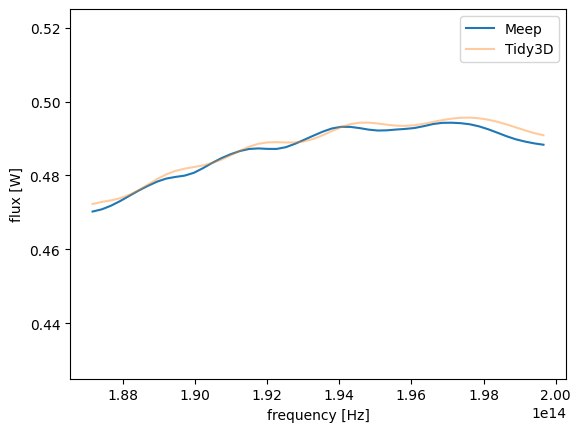

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 


fig,ax = plt.subplots()

#loading meep data
meep_data = np.loadtxt('misc/MeepMMI')
freqs = meep_data.T[0]
flux = meep_data.T[1]

ax.plot(freqs,flux,label = 'Meep')

        
sim_data['Flux monitor'].flux.plot(ax=ax,alpha = 0.4,label = 'Tidy3D')
ax.legend()
ax.set_ylim(0.425,0.525)

plt.show()